# Example match — event map

One half of one match, every on-ball action drawn on the pitch, one panel per team —
then the same machinery pointed at a single player.
Data comes from the staging Parquet layer (`data/staging/statsbomb/`), never raw JSON.

Match: **World Cup 2022 final** (looked up from the matches table, not hardcoded), **first half**.

Reading the pitch panels — shape carries the action type, color supports it:
- **thin arrows** = passes (solid blue completed, pale blue incomplete)
- **dashed arrows** = carries (only those ≥ 5 yd, to keep the map legible)
- **triangles** = dribbles / take-ons (filled = beat the man, open = failed)
- **stars** = shots, sized by xG
- **× marks** = fouls committed

StatsBomb records every event from the acting team's perspective, attacking left → right —
so each team's panel already points the right way, no flipping needed.
The faint dashed grid is the 6×5 zone binning the project later uses for spatial signatures.

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
CFG = yaml.safe_load(open(ROOT / "config.yaml"))
STAGING = ROOT / CFG["paths"]["staging"] / "statsbomb"

con = duckdb.connect()
final = con.sql(f"""
    SELECT * FROM '{STAGING}/matches/43_106.parquet'
    WHERE competition_stage = 'Final'
""").df().iloc[0]

ev = con.sql(f"""
    SELECT * FROM '{STAGING}/events/43_106.parquet'
    WHERE match_id = {final.match_id} AND period = 1
""").df()

teams = [final.home_team, final.away_team]
print(f"{final.competition} {final.season} final — "
      f"{final.home_team} {final.home_score}–{final.away_score} {final.away_team}")
print(f"first half: {len(ev):,} events")

FIFA World Cup 2022 final — Argentina 3–3 France
first half: 1,751 events


In [2]:
# light-mode slots of the project viz palette; shapes are the primary separator, hue supports
C = {
    "pass": "#2a78d6", "pass_fail": "#9ec5f4",   # completed / incomplete = two steps of one hue
    "carry": "#1baf7a",
    "shot": "#eb6834",
    "dribble": "#4a3aa7",
    "foul": "#e34948",
    "goal": "#0ca30c", "saved": "#2a78d6", "off": "#898781",  # goal-mouth statuses
    "ink": "#0b0b0b", "sub": "#52514e", "muted": "#898781",
    "line": "#c3c2b7", "grid": "#e1e0d9", "bg": "#fcfcfb",
}


def draw_pitch(ax):
    # StatsBomb pitch: 120 x 80 yards, origin top-left, attack toward x = 120
    ax.set_facecolor(C["bg"])
    line = dict(color=C["line"], lw=1.2, fill=False)
    ax.add_patch(patches.Rectangle((0, 0), 120, 80, **line))
    ax.add_patch(patches.Rectangle((0, 18), 18, 44, **line))     # penalty areas
    ax.add_patch(patches.Rectangle((102, 18), 18, 44, **line))
    ax.add_patch(patches.Rectangle((0, 30), 6, 20, **line))      # six-yard boxes
    ax.add_patch(patches.Rectangle((114, 30), 6, 20, **line))
    ax.add_patch(patches.Rectangle((-1.5, 36), 1.5, 8, **line))  # goals
    ax.add_patch(patches.Rectangle((120, 36), 1.5, 8, **line))
    ax.plot([60, 60], [0, 80], color=C["line"], lw=1.2)
    ax.add_patch(patches.Circle((60, 40), 10, **line))
    for x in (12, 108):
        ax.plot(x, 40, ".", color=C["line"], ms=4)
    # the 6x5 zone grid used later for spatial signatures
    for gx in range(20, 120, 20):
        ax.plot([gx, gx], [0, 80], color=C["grid"], lw=0.6, ls=(0, (2, 4)), zorder=0)
    for gy in range(16, 80, 16):
        ax.plot([0, 120], [gy, gy], color=C["grid"], lw=0.6, ls=(0, (2, 4)), zorder=0)
    ax.set_xlim(-3, 123)
    ax.set_ylim(-2, 82)
    ax.invert_yaxis()   # StatsBomb y grows downward; this puts each team's left wing on the left
    ax.set_aspect("equal")
    ax.axis("off")

In [3]:
def arrow(ax, x0, y0, x1, y1, color, lw, alpha, ls="-"):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color=color, lw=lw, alpha=alpha,
                                linestyle=ls, shrinkA=0, shrinkB=0))


def plot_events(ax, d, title):
    """Event map for any slice of staged events — a team's half, a player's match, ..."""
    draw_pitch(ax)

    passes = d[d.type == "Pass"]
    for _, p in passes.iterrows():
        ok = pd.isna(p.outcome)   # StatsBomb convention: no outcome = completed
        arrow(ax, p.x, p.y, p.pass_end_x, p.pass_end_y,
              C["pass"] if ok else C["pass_fail"], 0.7, 0.7 if ok else 0.75)

    carries = d[(d.type == "Carry")]
    carries = carries[((carries.carry_end_x - carries.x) ** 2
                       + (carries.carry_end_y - carries.y) ** 2) ** 0.5 >= 5]
    for _, c in carries.iterrows():
        arrow(ax, c.x, c.y, c.carry_end_x, c.carry_end_y, C["carry"], 1.1, 0.8, ls="--")

    drb = d[d.type == "Dribble"]
    won = drb[drb.outcome == "Complete"]
    lost = drb[drb.outcome != "Complete"]
    ax.scatter(won.x, won.y, marker="^", s=90, color=C["dribble"],
               edgecolor=C["bg"], lw=1, zorder=5)
    ax.scatter(lost.x, lost.y, marker="^", s=90, facecolor="none",
               edgecolor=C["dribble"], lw=1.6, zorder=5)

    fouls = d[d.type == "Foul Committed"]
    ax.scatter(fouls.x, fouls.y, marker="x", s=80, color=C["foul"], lw=2, zorder=5)

    shots = d[d.type == "Shot"]
    ax.scatter(shots.x, shots.y, marker="*", s=140 + 900 * shots.shot_xg.fillna(0),
               color=C["shot"], edgecolor=C["ink"], lw=0.6, zorder=6)

    n_ok = passes.outcome.isna().sum()
    legend = [
        Line2D([], [], color=C["pass"], lw=1.5, label=f"pass completed ({n_ok})"),
        Line2D([], [], color=C["pass_fail"], lw=1.5, label=f"pass incomplete ({len(passes) - n_ok})"),
        Line2D([], [], color=C["carry"], lw=1.5, ls="--", label=f"carry ≥5yd ({len(carries)})"),
        Line2D([], [], marker="^", color=C["dribble"], lw=0, ms=9,
               label=f"dribble won/lost ({len(won)}/{len(lost)})"),
        Line2D([], [], marker="*", color=C["shot"], lw=0, ms=13,
               label=f"shot, size = xG ({len(shots)})"),
        Line2D([], [], marker="x", color=C["foul"], lw=0, ms=8, mew=2,
               label=f"foul ({len(fouls)})"),
    ]
    ax.legend(handles=legend, loc="upper center", bbox_to_anchor=(0.5, -0.01),
              ncol=3, frameon=False, fontsize=9, labelcolor=C["sub"])
    ax.set_title(title, color=C["ink"], fontsize=13, pad=10)

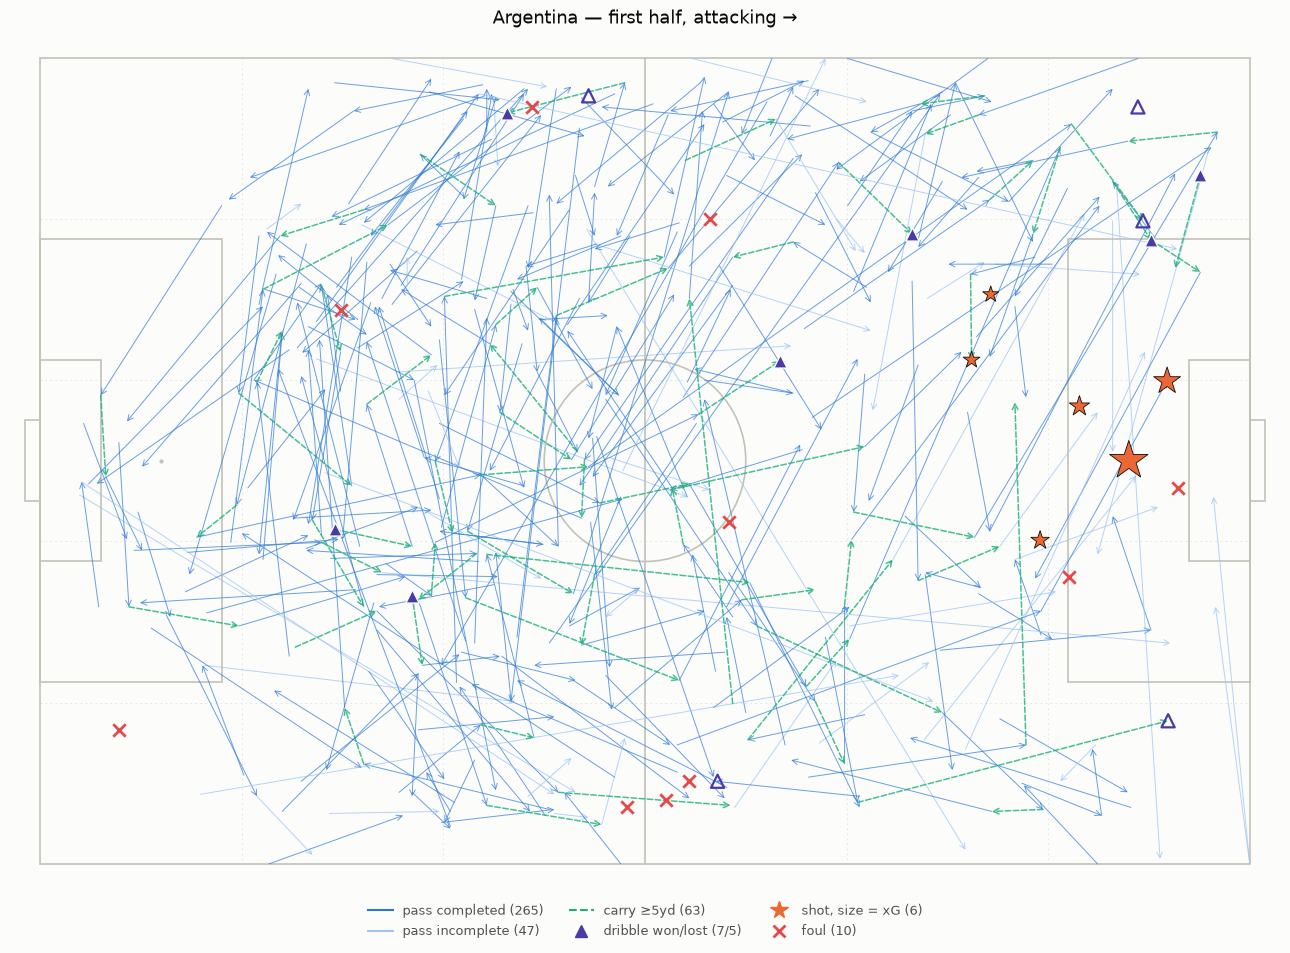

In [4]:
fig, ax = plt.subplots(figsize=(13, 10), facecolor=C["bg"])
plot_events(ax, ev[ev.team == teams[0]], f"{teams[0]} — first half, attacking →")
plt.tight_layout()
plt.show()

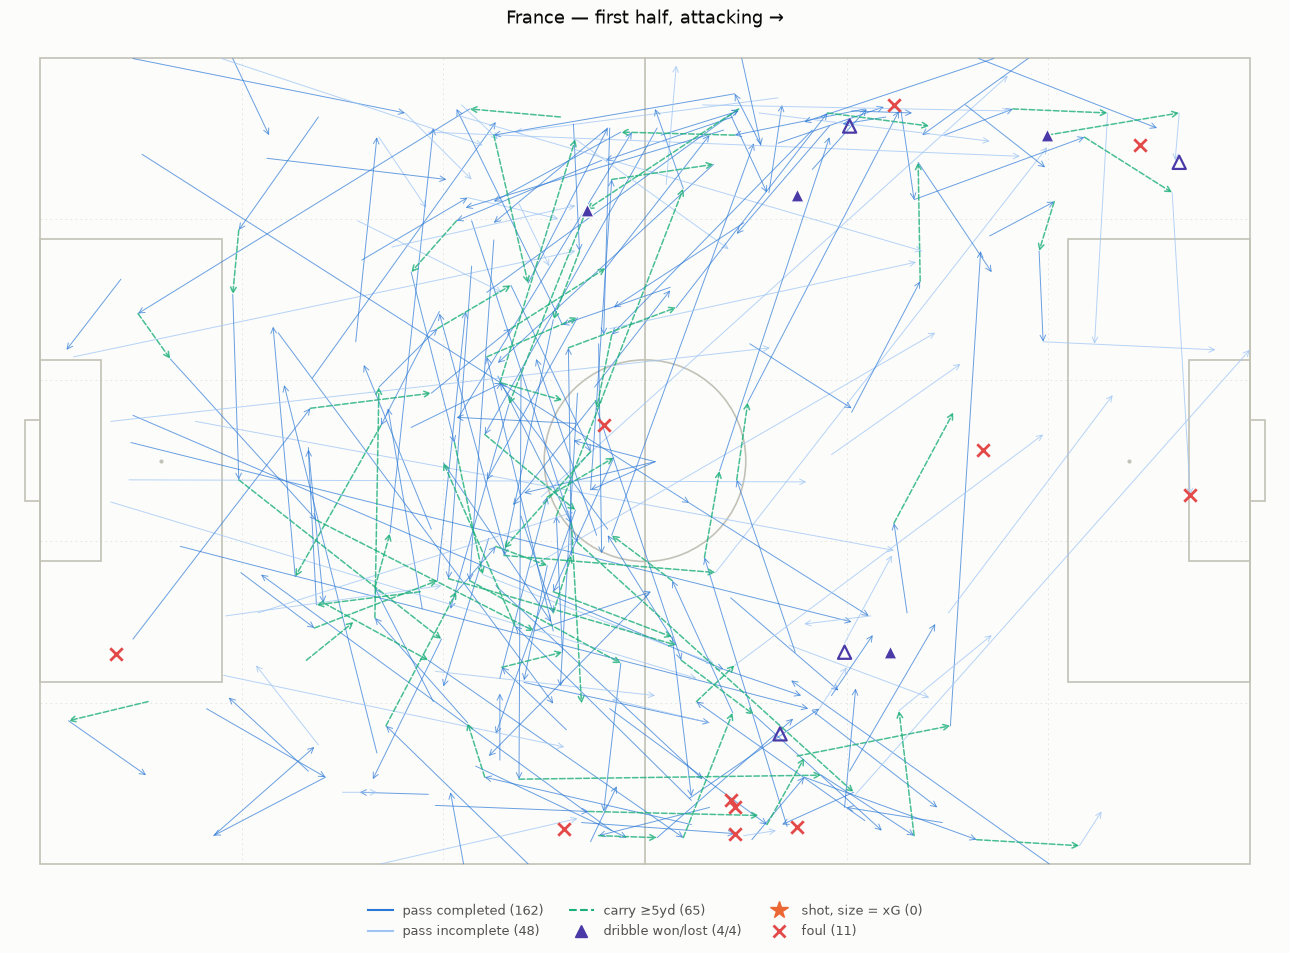

In [5]:
fig, ax = plt.subplots(figsize=(13, 10), facecolor=C["bg"])
plot_events(ax, ev[ev.team == teams[1]], f"{teams[1]} — first half, attacking →")
plt.tight_layout()
plt.show()

## Where the shots ended up — the goal mouth

Shot end locations have a **z coordinate** (height, yards) — the goal-mouth placement only
StatsBomb provides. Frame: posts at y = 36 and 44, crossbar at 2.67 yd.
Viewed from the shooter's position.

Outcomes are marked as three statuses: **goal** (green star), **saved** (blue circle),
**off target** (gray open circle — Off T / Post / Wayward). *Blocked* shots never reach
the goal line and are excluded (counted in the panel title).

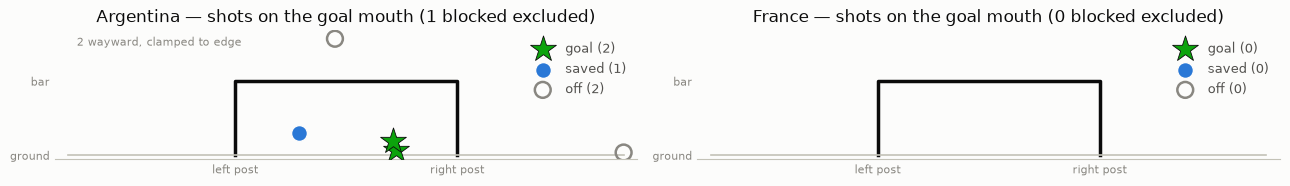

In [6]:
def shot_bucket(outcome):
    if outcome == "Goal":
        return "goal"
    if outcome in ("Saved", "Saved To Post"):
        return "saved"
    if outcome == "Blocked":
        return None
    return "off"   # Off T, Post, Wayward, Saved Off Target


def draw_goal_mouth(ax, shots, label):
    """Goal-mouth map for any slice of staged shot events."""
    shots = shots.copy()
    shots["bucket"] = shots.outcome.map(shot_bucket)
    blocked = shots.bucket.isna().sum()
    shots = shots.dropna(subset=["bucket"])
    shots["z"] = shots.shot_end_z.fillna(0.1)   # no z recorded = along the ground

    ax.set_facecolor(C["bg"])
    ax.plot([36, 36, 44, 44], [0, 2.67, 2.67, 0], color=C["ink"], lw=2.5)  # frame
    ax.plot([30, 50], [0, 0], color=C["line"], lw=1.2)                     # goal line

    # fixed shared view so panels compare 1:1;
    # very wayward shots are clamped to the edge and counted, never silently clipped
    y_view, z_view = (30.0, 50.0), (0.0, 4.2)
    clamped = ((shots.shot_end_y < y_view[0]) | (shots.shot_end_y > y_view[1])
               | (shots.z > z_view[1])).sum()
    shots["py"] = shots.shot_end_y.clip(*y_view)
    shots["pz"] = shots.z.clip(*z_view)

    style = {"goal": dict(marker="*", s=380, color=C["goal"], edgecolor=C["ink"], lw=0.6),
             "saved": dict(marker="o", s=130, color=C["saved"], edgecolor=C["bg"], lw=1),
             "off": dict(marker="o", s=130, facecolor="none", edgecolor=C["off"], lw=1.8)}
    for bucket, st in style.items():
        b = shots[shots.bucket == bucket]
        ax.scatter(b.py, b.pz, **st, zorder=5, label=f"{bucket} ({len(b)})")
    if clamped:
        ax.text(y_view[0] + 0.3, z_view[1] - 0.25, f"{clamped} wayward, clamped to edge",
                ha="left", color=C["muted"], fontsize=8)

    ax.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=C["sub"])
    ax.set_title(f"{label} — shots on the goal mouth ({blocked} blocked excluded)",
                 color=C["ink"], fontsize=12)
    ax.set_xlim(y_view[0] - 0.5, y_view[1] + 0.5)
    ax.set_ylim(-0.15, z_view[1] + 0.3)
    ax.set_aspect("equal")
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(C["line"])
    ax.set_yticks([0, 2.67])
    ax.set_yticklabels(["ground", "bar"], color=C["muted"], fontsize=8)
    ax.set_xticks([36, 44])
    ax.set_xticklabels(["left post", "right post"], color=C["muted"], fontsize=8)
    ax.tick_params(length=0)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), facecolor=C["bg"])
for ax, team in zip(axes, teams):
    draw_goal_mouth(ax, ev[(ev.type == "Shot") & (ev.team == team)], team)
plt.tight_layout()
plt.show()

## Isolating one player

This is the project's unit of analysis in action: because every staged row carries
`player_id` alongside the match/competition/season keys, "all of Messi's actions" is a
`WHERE` clause — no restructuring, the same plotting functions just receive a smaller slice.

Below: Messi's **whole final** (periods 1–4, i.e. including extra time; the penalty
shootout is excluded — shootout kicks are a different context from open play).

In [7]:
# resolve the id once, then key on it — names are display, ids are identity
messi_id = int(con.sql(f"""
    SELECT DISTINCT player_id FROM '{STAGING}/events/43_106.parquet'
    WHERE player ILIKE '%Messi Cuccittini%'
""").df().player_id[0])

messi = con.sql(f"""
    SELECT * FROM '{STAGING}/events/43_106.parquet'
    WHERE match_id = {final.match_id} AND player_id = {messi_id} AND period <= 4
""").df()

print(f"player_id {messi_id}: {len(messi):,} events in the final (periods 1–4)")
print(messi.type.value_counts().to_string())

player_id 5503: 241 events in the final (periods 1–4)
type
Ball Receipt*      74
Pass               60
Carry              53
Pressure           17
Ball Recovery       7
Dispossessed        6
Shot                5
Miscontrol          3
Dribble             3
Duel                3
Foul Committed      2
Foul Won            2
Injury Stoppage     1
Player Off          1
Player On           1
Offside             1
Clearance           1
Block               1


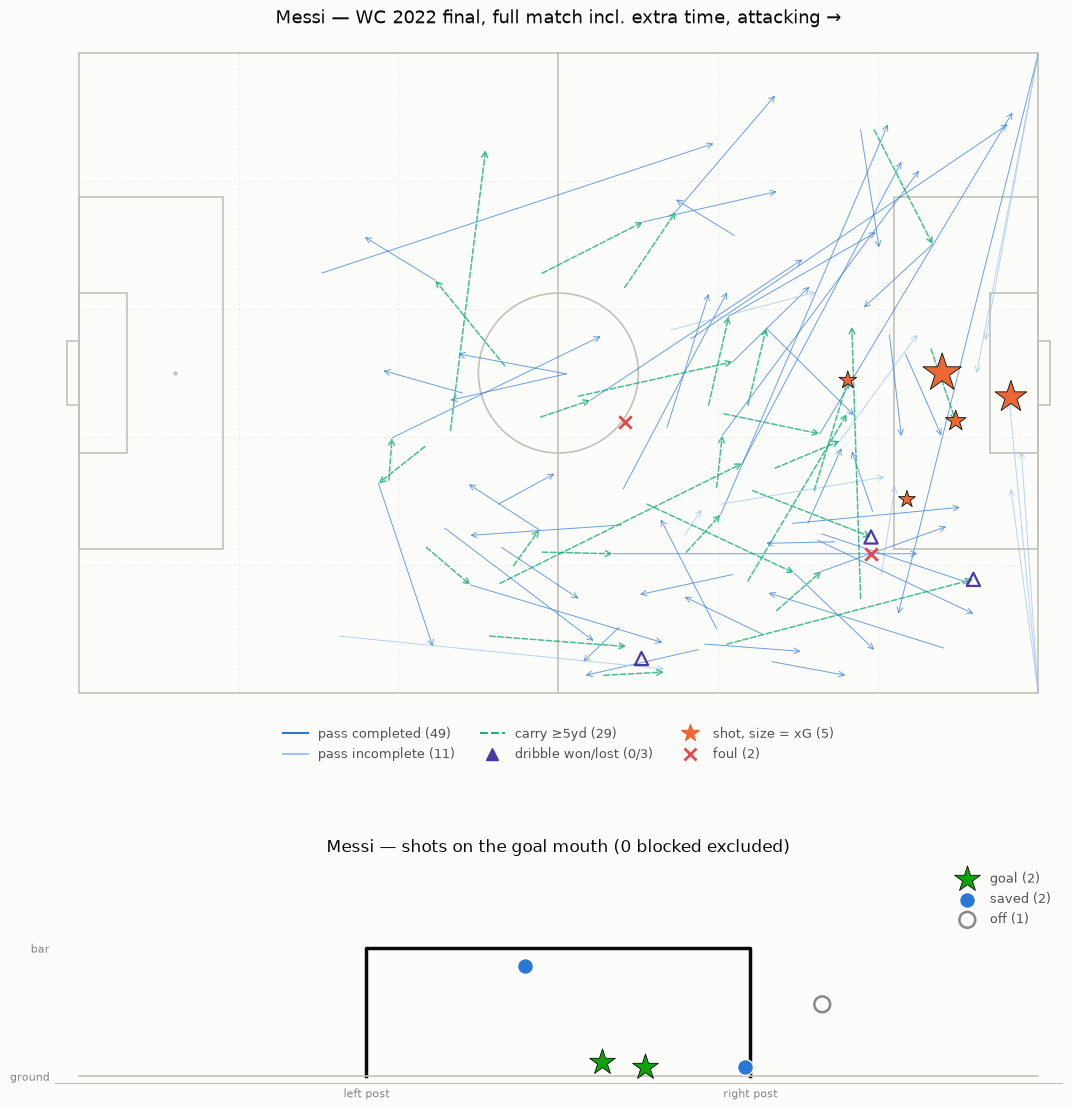

In [8]:
fig = plt.figure(figsize=(13, 14), facecolor=C["bg"])
gs = fig.add_gridspec(2, 1, height_ratios=[2.6, 1], hspace=0.25)
plot_events(fig.add_subplot(gs[0]), messi,
            "Messi — WC 2022 final, full match incl. extra time, attacking →")
draw_goal_mouth(fig.add_subplot(gs[1]), messi[messi.type == "Shot"], "Messi")
plt.show()

### One season, two entities: club and country

The unit of comparison is one **season** of one player — but within a season, all **club**
competitions pool into a single entity (league + cups belong to the same playing context),
and **national-team** competitions pool into their own, separate entity. StatsBomb's
`competition_international` flag makes the split (Champions League correctly counts as club).

Penalty shootouts (period 5) are excluded from every count — a shootout kick is not
open-play behaviour, and shootout "goals" would silently inflate goal tallies.

Example: Messi 2014/15 at club level pools La Liga with the Champions League final;
Messi's 2022 country entity is the World Cup alone.

In [9]:
import json

# club vs country comes from competitions.json, not guessed from names
flags = pd.DataFrame(json.load(open(ROOT / CFG["paths"]["statsbomb"] / "competitions.json")))
flags = flags[["competition_id", "season_id", "competition_international"]].drop_duplicates()
con.register("comp_flags", flags)


def season_entity(player_id, season_name, context):
    """One (player, season, context) entity: all competitions of that context pooled."""
    intl = "true" if context == "country" else "false"
    return con.sql(f"""
        WITH names AS (
            SELECT DISTINCT competition_id, season_id, competition, season
            FROM '{STAGING}/matches/*.parquet')
        SELECT '{context}' AS context, n.season,
               string_agg(DISTINCT n.competition, ' + ') AS competitions,
               count(DISTINCT e.match_id) AS matches,
               count(*) AS actions,
               sum(CASE WHEN e.type = 'Shot' AND e.outcome = 'Goal' THEN 1 ELSE 0 END) AS goals
        FROM '{STAGING}/events/*.parquet' e
        JOIN names n USING (competition_id, season_id)
        JOIN comp_flags f USING (competition_id, season_id)
        WHERE e.player_id = {player_id}
          AND e.period <= 4              -- shootouts never count
          AND n.season = '{season_name}'
          AND f.competition_international = {intl}
        GROUP BY n.season
    """).df()


pd.concat([
    season_entity(messi_id, "2014/2015", "club"),   # La Liga + CL final, one entity
    season_entity(messi_id, "2022", "country"),     # World Cup 2022, its own entity
], ignore_index=True)

,context,season,competitions,matches,actions,goals
0,club,2014/2015,La Liga + Champions League,39,9988,43.0
1,country,2022,FIFA World Cup,7,1551,7.0


## Caveats

- Coordinates are per **acting team** (always attacking left → right), so panels are directly
  comparable but cannot be overlaid on one shared pitch without flipping one team.
- Carries under 5 yards are hidden on the pitch map only — they exist in the data.
- A shot's `outcome` lives in the unified `outcome` column of the staging schema; penalties and
  open-play shots are not distinguished here (see `shot_type` if needed).
- This notebook is exploration, not pipeline (PLAN Part 11) — nothing downstream reads it.